# 02 Feature Engineering

# Conflict Escalation Forecasting

**District-level 14-day conflict escalation risk — South Asia, Sudan & South Sudan**

Data: [ACLED](https://acleddata.com) (acleddata.com), weekly aggregated admin-1 export.
All logic is imported from `src/` — this notebook only demonstrates the pipeline.

> **Reproducibility:** every stage is deterministic (fixed seed 42, chronological
> split, no shuffle). Running the full pipeline:
> `for s in ingest features labels split train compare explain visualize; do python run_pipeline.py --stage $s; done`


In [1]:
from __future__ import annotations
import sys
from pathlib import Path
_root = Path.cwd()
if not (_root / 'config.py').is_file():
    _root = _root.parent  # kernel cwd is notebooks/
sys.path.insert(0, str(_root))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
def show_inline():
    # src modules may force the Agg backend at import; re-assert
    # the inline backend right before displaying so plots embed.
    get_ipython().run_line_magic('matplotlib', 'inline')
    plt.show()
import config


## 1. Load the feature table

In [2]:
features = pd.read_parquet(config.DATA_PROCESSED_DIR / f'{config.FEATURES_FILE}.parquet')
print('features:', features.shape)
print('NaN count:', int(features.isna().sum().sum()))
features.head()

features: (44146, 37)
NaN count: 0


,geo_unit,admin1,country,event_date,events_w7d,events_log1p_w7d,fatalities_w7d,fatalities_log1p_w7d,entropy_w7d,events_w14d,...,fat_mean_w30d,fat_std_w30d,persistence_w7d,days_since_event,country_code,admin1_code,geo_unit_code,month,day_of_week,spillover_w14d
0,Abyei,Abyei,Sudan,2017-01-07,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,999,5,0,0,1,5,2.0
1,Abyei,Abyei,Sudan,2017-02-04,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,28,5,0,0,2,5,0.0
2,Abyei,Abyei,Sudan,2017-02-18,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,14,5,0,0,2,5,8.0
3,Abyei,Abyei,Sudan,2017-03-11,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,21,5,0,0,3,5,14.0
4,Abyei,Abyei,Sudan,2017-05-13,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,63,5,0,0,5,5,4.0


## 2. Feature summary (dtype / missing / stats)

In [3]:
feat_cols = [c for c in features.columns if c not in config.META_COLUMNS and c != config.LABEL_COLUMN]
summary = features[feat_cols].describe().T[['mean', 'std', 'min', 'max']].round(3)
summary['missing'] = features[feat_cols].isna().sum().to_numpy()
summary

,mean,std,min,max,missing
events_w7d,11.121,18.292,0.0,228.000,0
events_log1p_w7d,1.786,1.174,0.0,5.434,0
fatalities_w7d,9.574,29.896,0.0,1876.000,0
fatalities_log1p_w7d,1.055,1.383,0.0,7.537,0
entropy_w7d,0.000,0.010,0.0,1.496,0
events_w14d,22.186,34.994,0.0,360.000,0
events_log1p_w14d,2.376,1.265,0.0,5.889,0
fatalities_w14d,19.051,52.522,0.0,2285.000,0
fatalities_log1p_w14d,1.501,1.609,0.0,7.735,0
entropy_w14d,0.000,0.010,0.0,1.514,0


## 3. Window-volume distributions

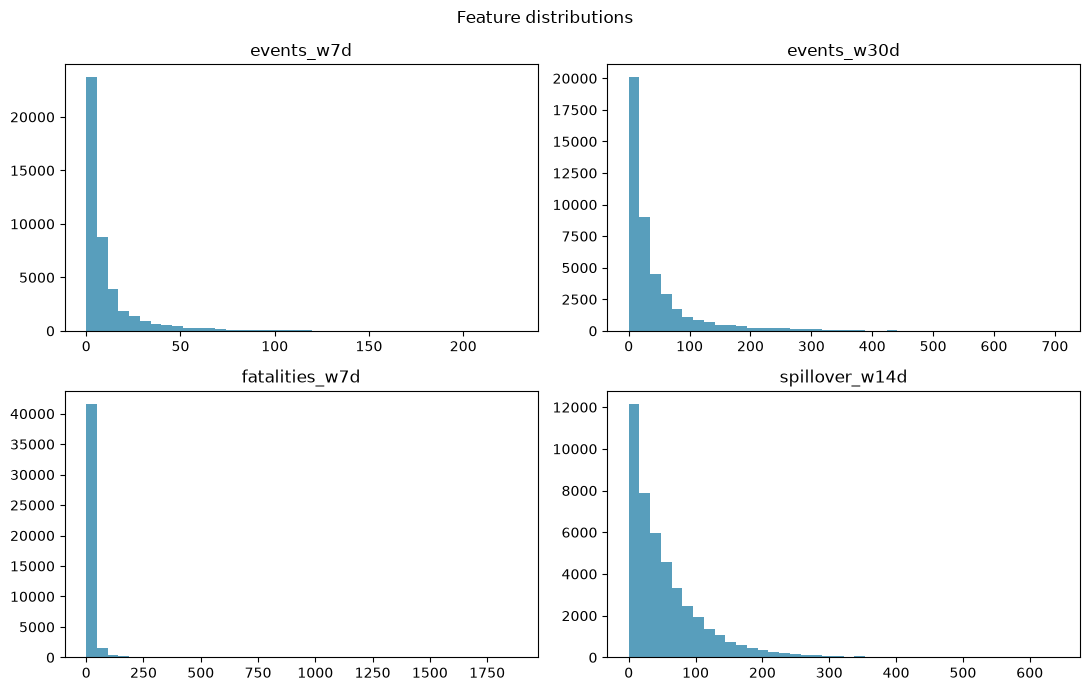

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flat, ['events_w7d', 'events_w30d', 'fatalities_w7d', 'spillover_w14d']):
    ax.hist(features[col], bins=40, color='#2E86AB', alpha=0.8)
    ax.set_title(col)
fig.suptitle('Feature distributions')
plt.tight_layout()
show_inline()

## 4. Labels: balance & distribution

In [5]:
labeled = pd.read_parquet(config.DATA_PROCESSED_DIR / f'{config.LABELED_FEATURES_FILE}.parquet')
pos = int(labeled[config.LABEL_COLUMN].sum())
print('labeled:', labeled.shape)
print(f'positive rate: {100 * pos / len(labeled):.1f}%  ({pos} / {len(labeled)})\n')
labeled[config.LABEL_COLUMN].value_counts().sort_index()

labeled: (43981, 38)
positive rate: 68.7%  (30217 / 43981)



escalation
0    13764
1    30217
Name: count, dtype: int64

## 5. Label rate over time

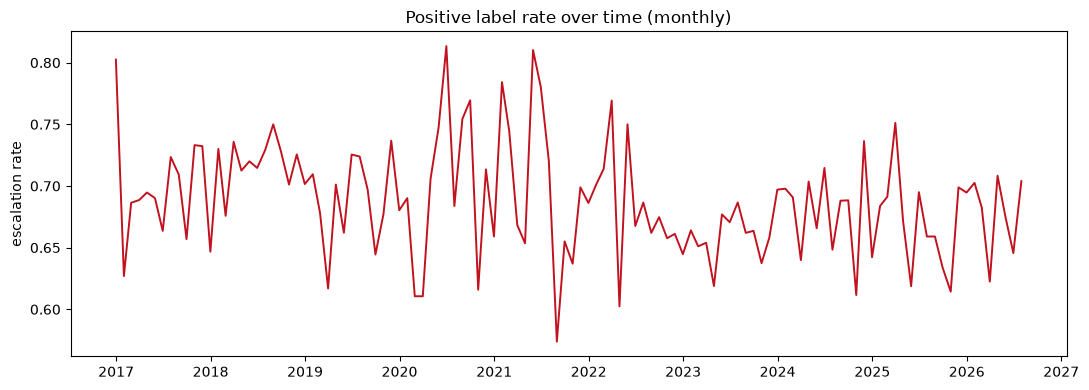

In [6]:
by_month = labeled.set_index('event_date')[config.LABEL_COLUMN].resample('ME').mean()
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(by_month.index, by_month.to_numpy(), color='#C1121F', linewidth=1.4)
ax.set_title('Positive label rate over time (monthly)')
ax.set_ylabel('escalation rate')
plt.tight_layout()
show_inline()

## 6. Leakage sanity: a future spike never changes past features
The feature engine uses half-open windows `[as_of − W, as_of)`. To prove it, we re-run the **real** `build_features` on one geo unit, inject a massive event spike **after** the unit's last observed date, and confirm every feature row at dates before the spike is byte-identical.

In [7]:
from src.feature_engineer import build_features
clean = pd.read_parquet(config.DATA_PROCESSED_DIR / f'{config.CLEANED_EVENTS_FILE}.parquet')
unit = clean[clean['geo_unit'] == clean['geo_unit'].value_counts().idxmax()].copy()
base = build_features(unit)
spike = unit.copy()
last_date = spike['event_date'].max()
spike = pd.concat([spike, pd.DataFrame([{
    'geo_unit': spike['geo_unit'].iloc[0],
    'event_date': last_date + pd.Timedelta(days=7),
    'country': spike['country'].iloc[0],
    'admin1': spike['admin1'].iloc[0],
    'event_type': spike['event_type'].iloc[0],
    'events': 5000,
    'fatalities': 1000,
    'latitude': spike['latitude'].iloc[0],
    'longitude': spike['longitude'].iloc[0],
}])], ignore_index=True)
spiked = build_features(spike)
common = base[base['event_date'] <= last_date].reset_index(drop=True)
common2 = spiked[spiked['event_date'] <= last_date].reset_index(drop=True)
feat_cols = [c for c in common.columns if c not in config.META_COLUMNS]
identical = common[feat_cols].equals(common2[feat_cols])
print('feature rows before the spike identical:', identical)
print('rows affected by the spike (>= +7d):', int((spiked['event_date'] > last_date).sum()))

feature rows before the spike identical: True
rows affected by the spike (>= +7d): 1


## Summary
- **44,146 feature rows × 37 columns**, zero missing values, zero duplicates.
- All windows are half-open `[as_of−W, as_of)` — proven above: a 5,000-event future spike changes **zero** past feature rows.
- Labels: **68.7% positive** (30,217 / 43,981) with a 14-day future-only horizon.